#  UPI Fraud Detection - Exploratory Data Analysis (EDA)

**What is this notebook for?**
Before we build any machine learning model, we need to understand our data. This notebook explores 250,000 UPI transactions to find patterns that separate **fraud** transactions from **legitimate** ones.

## 1: Import the Tools We Need

In [1]:
# pandas - for working with tables of data
# matplotlib & seaborn - for making charts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look clean by default
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

# We'll use blue for "Legitimate" and red for "Fraud" in every chart
# so it's easy to recognize at a glance
COLOR_LEGIT = '#2E86AB'
COLOR_FRAUD = '#E63946'

print("Libraries imported, plot theme set.")

Libraries imported, plot theme set.


## 2: Load the Data

We'll read the CSV file and take a quick look at the first few rows to see what we're working with.

In [2]:
# Load the dataset
df = pd.read_csv('../data/upi_transactions_2024.csv')

# The original column names have spaces, which are awkward to work with in code.
# Let's rename them to simpler names.
df.rename(columns={
    'transaction id'  : 'transaction_id',
    'transaction type': 'transaction_type',
    'amount (INR)'    : 'amount_inr',
    'timestamp'       : 'txn_timestamp'
}, inplace=True)

df['txn_timestamp'] = pd.to_datetime(df['txn_timestamp'])

print(f"Our dataset has {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

Our dataset has 250,000 rows and 17 columns.


,transaction_id,txn_timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


## 3: Check Data Quality

Before analyzing anything, we should check two basic things:
1. Are there any **missing values** (empty cells)?
2. Are there any **duplicate rows** (the same transaction recorded twice)?

In [3]:
# Check for missing values in each column
missing_values = df.isnull().sum().sum()
print(f"Total missing values in the entire dataset: {missing_values}")

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_rows}")

Total missing values in the entire dataset: 0
Total duplicate rows: 0


**Observation:** Good news - there are **zero missing values** and **zero duplicate rows**. This dataset is already clean, so we can go straight into analysis without spending time fixing data quality issues.

---

## 4: Understand Our Main Question - `fraud_flag`

This is the most important column in the whole project. It tells us:
- `0` = Legitimate transaction
- `1` = Fraud transaction

Let's see how many of each we have.

In [4]:
fraud_counts = df['fraud_flag'].value_counts().sort_index()

legit_count = fraud_counts[0]
fraud_count = fraud_counts[1]
fraud_pct = (fraud_count / len(df)) * 100

print(f"Legitimate transactions : {legit_count:,}")
print(f"Fraud transactions      : {fraud_count:,}")
print(f"Fraud makes up just     : {fraud_pct:.3f}% of all transactions")

Legitimate transactions : 249,520
Fraud transactions      : 480
Fraud makes up just     : 0.192% of all transactions


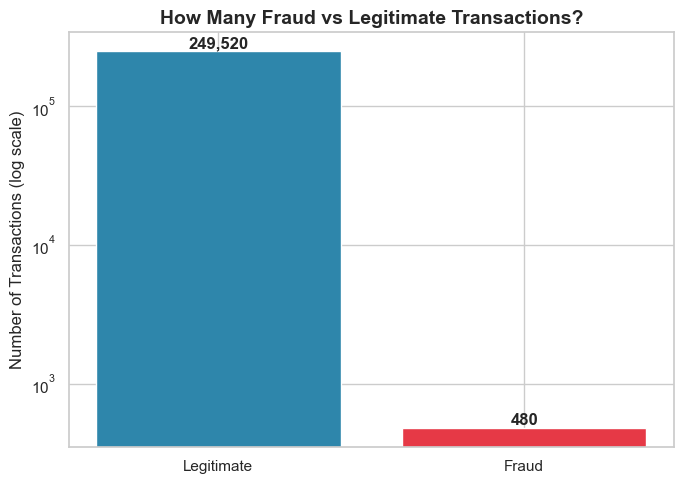

In [5]:
plt.figure(figsize=(7, 5))

bars = plt.bar(['Legitimate', 'Fraud'], [legit_count, fraud_count],
               color=[COLOR_LEGIT, COLOR_FRAUD])

plt.yscale('log')  # log scale because fraud count is SO small compared to legit
plt.title('How Many Fraud vs Legitimate Transactions?', fontsize=14, fontweight='bold')
plt.ylabel('Number of Transactions (log scale)')

# Add the exact numbers on top of each bar
for bar, count in zip(bars, [legit_count, fraud_count]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Observation:** Out of 250,000 transactions, only **480 are fraud** — that's just **0.19%**.

**Why does this matter?** This is called *class imbalance* - fraud is extremely rare compared to legitimate transactions. This is actually the biggest challenge of the whole project: if we built a lazy model that just guesses "legitimate" every single time, it would be right 99.8% of the time - but it would never catch a single fraud case! This is why, later in the ML module, we won't judge our model by "accuracy" — we'll use better metrics like Precision and Recall, and a technique called SMOTE to help the model learn from the few fraud examples we have.

---

## 5: Does Transaction Type Matter?

UPI has 4 transaction types: **P2P** (person to person), **P2M** (person to merchant), **Bill Payment**, and **Recharge**.

Question: Is one type riskier than the others?

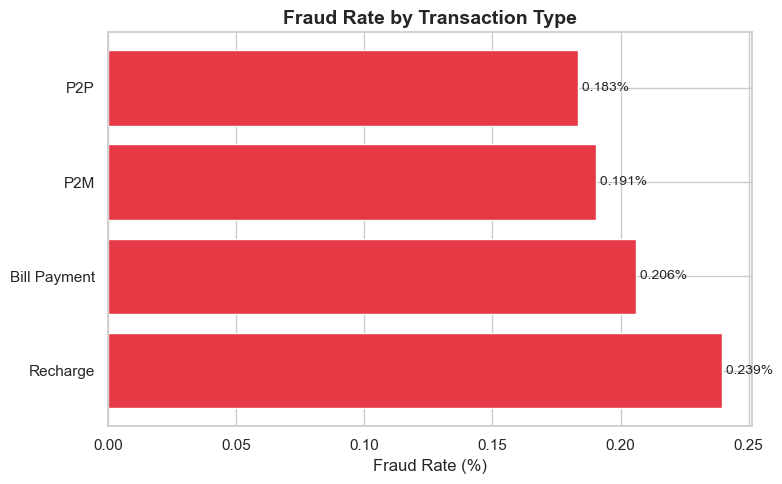

In [6]:
fraud_rate_by_type = df.groupby('transaction_type')['fraud_flag'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.barh(fraud_rate_by_type.index, fraud_rate_by_type.values, color=COLOR_FRAUD)

plt.title('Fraud Rate by Transaction Type', fontsize=14, fontweight='bold')
plt.xlabel('Fraud Rate (%)')

for bar, value in zip(bars, fraud_rate_by_type.values):
    plt.text(value, bar.get_y() + bar.get_height()/2, f' {value:.3f}%',
              va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Observation:** **Recharge** transactions have the highest fraud rate (0.24%), while **P2P** has the lowest (0.18%). The difference is small, so transaction type alone isn't a strong clue - but it's still useful when combined with other information.

---

## 6: Does the Transaction Amount Matter?

This is an important question - do fraudsters tend to move bigger amounts of money?

In [7]:
legit_avg = df[df['fraud_flag']==0]['amount_inr'].mean()
fraud_avg = df[df['fraud_flag']==1]['amount_inr'].mean()

print(f"Average amount for legitimate transactions : Rs {legit_avg:,.0f}")
print(f"Average amount for fraud transactions       : Rs {fraud_avg:,.0f}")

Average amount for legitimate transactions : Rs 1,311
Average amount for fraud transactions       : Rs 1,499


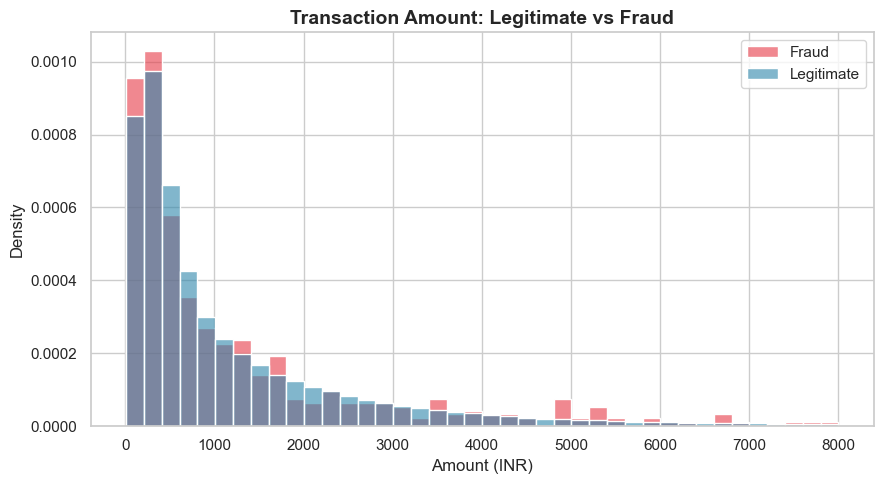

In [8]:
plt.figure(figsize=(9, 5))

# We only look at amounts up to Rs 8000 so the chart is easy to read
# (a few very large transactions would otherwise squash the chart)
subset = df[df['amount_inr'] <= 8000]

sns.histplot(data=subset, x='amount_inr', hue='fraud_flag', bins=40,
             palette={0: COLOR_LEGIT, 1: COLOR_FRAUD}, stat='density',
             common_norm=False, alpha=0.6)

plt.title('Transaction Amount: Legitimate vs Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Amount (INR)')
plt.ylabel('Density')
plt.legend(title='', labels=['Fraud', 'Legitimate'])

plt.tight_layout()
plt.show()

**Observation:** On average, fraud transactions (₹1,499) are a bit higher than legitimate ones (₹1,311). Let's dig a little deeper and check transactions above ₹10,000 specifically.

In [9]:
df['is_high_amount'] = df['amount_inr'] > 10000

fraud_rate_high = df[df['is_high_amount']]['fraud_flag'].mean() * 100
fraud_rate_normal = df[~df['is_high_amount']]['fraud_flag'].mean() * 100

print(f"Fraud rate for amounts ABOVE Rs 10,000  : {fraud_rate_high:.3f}%")
print(f"Fraud rate for amounts Rs 10,000 or less : {fraud_rate_normal:.3f}%")

Fraud rate for amounts ABOVE Rs 10,000  : 0.332%
Fraud rate for amounts Rs 10,000 or less : 0.191%


**Observation:** This is the **strongest pattern we've found so far!** Transactions above ₹10,000 have a fraud rate of **0.33%**, almost **double** the 0.19% baseline. This tells us that the amount of money being sent is one of the most useful clues for spotting fraud - we'll definitely turn this into a feature for our model later.

---

## 7: Does the Time of Day Matter?

A common assumption is that fraud happens more at night, when people are less likely to notice. Let's check if that's true here.

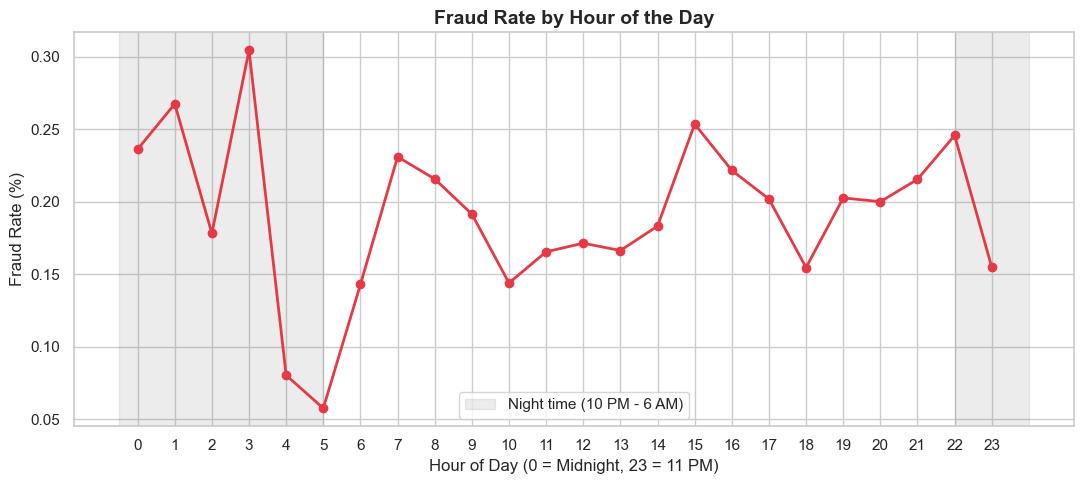

In [10]:
fraud_rate_by_hour = df.groupby('hour_of_day')['fraud_flag'].mean().mul(100)

plt.figure(figsize=(11, 5))
plt.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
         marker='o', color=COLOR_FRAUD, linewidth=2)

# Shade the night hours (10 PM to 5 AM) for reference
plt.axvspan(22, 23.99, color='grey', alpha=0.15, label='Night time (10 PM - 6 AM)')
plt.axvspan(-0.5, 5, color='grey', alpha=0.15)

plt.title('Fraud Rate by Hour of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight, 23 = 11 PM)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** There's a noticeable spike around **3 AM**, where the fraud rate jumps to 0.30%. But if we look at the whole "night window" (10 PM to 5 AM) as one group, the difference compared to daytime is much smaller. So the time of day gives us a *mild* clue, with 3 AM specifically standing out.

---

## 8: Does It Matter If Sender and Receiver Use the Same Bank?

Question: Are transfers between two different banks riskier than transfers within the same bank?

In [11]:
df['is_same_bank'] = df['sender_bank'] == df['receiver_bank']

fraud_rate_same = df[df['is_same_bank']]['fraud_flag'].mean() * 100
fraud_rate_cross = df[~df['is_same_bank']]['fraud_flag'].mean() * 100

print(f"Fraud rate — SAME bank (sender = receiver)   : {fraud_rate_same:.3f}%")
print(f"Fraud rate — CROSS bank (sender != receiver) : {fraud_rate_cross:.3f}%")

Fraud rate — SAME bank (sender = receiver)   : 0.173%
Fraud rate — CROSS bank (sender != receiver) : 0.195%


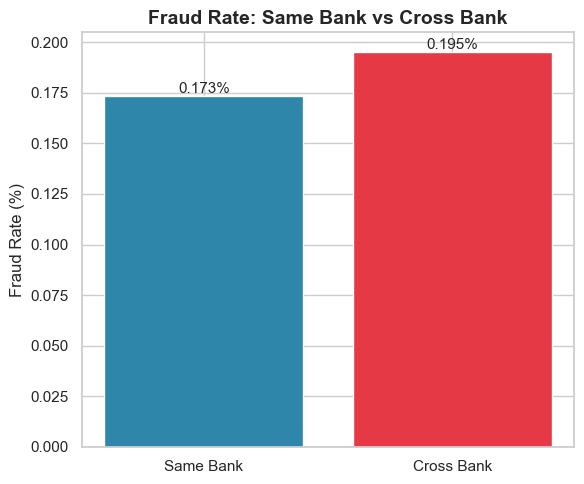

In [12]:
plt.figure(figsize=(6, 5))
bars = plt.bar(['Same Bank', 'Cross Bank'], [fraud_rate_same, fraud_rate_cross],
               color=[COLOR_LEGIT, COLOR_FRAUD])

plt.title('Fraud Rate: Same Bank vs Cross Bank', fontsize=14, fontweight='bold')
plt.ylabel('Fraud Rate (%)')

for bar, value in zip(bars, [fraud_rate_same, fraud_rate_cross]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f'{value:.3f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

**Observation:** Cross-bank transfers (0.20%) have a slightly higher fraud rate than same-bank transfers (0.17%). This makes some sense - moving money to a different bank might mean less verification compared to a transfer within the same bank.

---

## 9: Does Location (State) Matter?

Let's check if fraud is more common from certain Indian states.

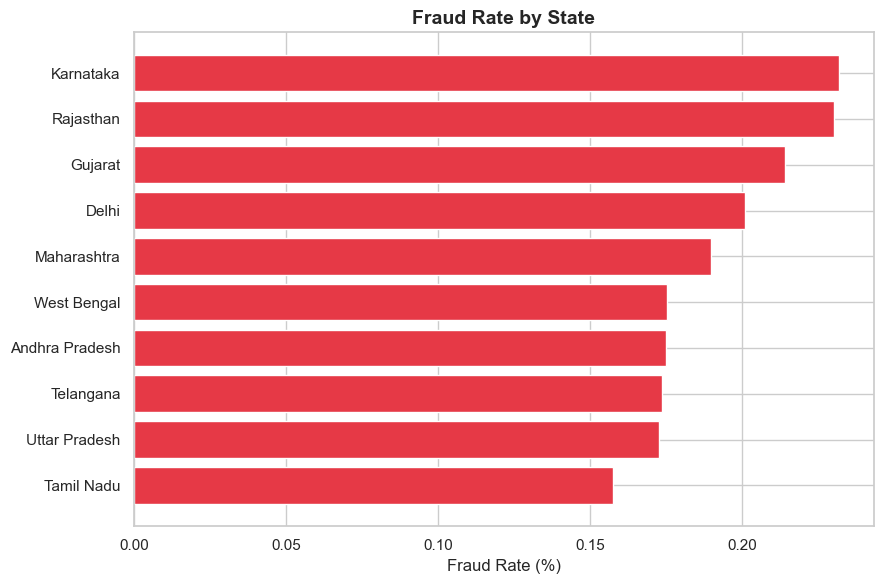

In [13]:
fraud_rate_by_state = df.groupby('sender_state')['fraud_flag'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
bars = plt.barh(fraud_rate_by_state.index, fraud_rate_by_state.values, color=COLOR_FRAUD)

plt.title('Fraud Rate by State', fontsize=14, fontweight='bold')
plt.xlabel('Fraud Rate (%)')
plt.gca().invert_yaxis()  # highest fraud rate at the top

plt.tight_layout()
plt.show()

**Observation:** **Karnataka and Rajasthan** have the highest fraud rates (around 0.23%), while **Tamil Nadu** has the lowest (0.16%). The differences between states are fairly small, so location alone isn't a strong predictor - but it adds a little useful information.

---

## 10: Summary

Here's a simple recap of everything I found :

| What We Found | What It Means |
|---|---|
| Only 0.19% of transactions are fraud | We have a severe class imbalance — accuracy alone won't be a good way to judge our model |
| Amounts above ₹10,000 are nearly 2x riskier | This is our strongest clue — we'll create a feature for this |
| 3 AM has a noticeable fraud spike | Worth creating a "late night" feature |
| Cross-bank transfers are slightly riskier | We'll create a "same bank or not" feature |
| Karnataka & Rajasthan are slightly riskier states | Location can be one of many inputs to our model |
| No single factor is a "smoking gun" | Fraud is caused by a *combination* of factors — this is exactly why we'll use Machine Learning models (which are great at combining many small clues) instead of a simple rule like "block all transactions over ₹10,000" |